## Tutorial: Model interpretability for chemical machine learning

In this tutorial, we will use the same MoleculeNet **blood–brain barrier penetration** (BBBP) dataset that we used in the first supervised learning tutorial. The dataset contains small molecules labeled according to whether they are reported to penetrate the blood–brain barrier.

The blood–brain barrier is a highly selective biological barrier that separates the brain from circulating blood. It helps protect the central nervous system by limiting the entry of many foreign molecules, toxins, and pathogens. This protection is essential for brain function, but it also means that many therapeutic molecules cannot reach the brain at sufficient concentrations. Predicting blood–brain barrier penetration is therefore important for both central nervous system drug design and safety assessment. For drugs intended to treat brain diseases, such as neurological or psychiatric disorders, BBB penetration is often desirable. For drugs intended to act outside the brain, BBB penetration may be undesirable because it can increase the risk of central nervous system side effects. A model that predicts BBB permeability can therefore help researchers prioritize molecules earlier in the discovery process.

This is also a useful example for chemical machine learning because the prediction task is chemically meaningful but not trivial. Blood–brain barrier permeability depends on molecular properties such as size, polarity, hydrogen bonding, lipophilicity, molecular flexibility, and molecular shape. The input to the model is a molecular structure, usually represented by a SMILES string. In this notebook, we will convert each molecule into chemically interpretable descriptors such as molecular weight, logP, topological polar surface area, hydrogen-bond donor and acceptor counts, ring count, and rotatable bond count. We will then train models to predict the binary BBBP label:

- `1`: BBB-penetrant
- `0`: BBB-nonpenetrant

These labels are commonly interpreted using a logBB threshold: molecules with $\log BB \ge -1$ are treated as BBB-penetrant, while molecules with $\log BB < -1$ are treated as BBB-nonpenetrant. Here, $\log BB$ is the logarithm of the ratio of the compound concentration in brain to its concentration in blood.

MoleculeNet is a benchmark collection for molecular machine learning that includes both regression and classification tasks. BBBP is one of its classification datasets. The commonly used MoleculeNet BBBP version contains 2,039 molecules and is class imbalanced, with many more BBB-positive than BBB-negative examples.

Interpretability is especially important in chemical machine learning because it allows us to learn what molecular patterns models appear to rely on. In a drug-discovery setting, an interpretable model can help researchers identify property tradeoffs, prioritize molecules for synthesis or testing, diagnose whether a model is using chemically meaningful signals or dataset artifacts, and generate hypotheses for future molecular design. For example, if a model consistently penalizes high polar surface area or many hydrogen-bond donors, that explanation may suggest ways to modify a molecule to improve passive BBB permeability. If the model relies on unexpected fingerprint bits or suspicious dataset-specific patterns, that may instead indicate a shortcut that should be investigated before trusting the model.

Throughout this tutorial, we will use interpretability methods to ask:

- Which molecular descriptors do models rely on globally?
- How do descriptors such as molecular weight, logP, and polar surface area affect predicted BBB permeability?
- Why did the model classify a particular molecule as BBB-penetrant or nonpenetrant?
- Are the explanations chemically reasonable, or could models be using shortcuts or dataset artifacts?
- How could these explanations guide future experiments, molecular design, or data collection?

We will compare several interpretability approaches:

1. **Interpretability by design**: logistic regression coefficients
2. **Model-agnostic global interpretability**: permutation importance  
3. **Feature-effect methods**: ICE and PDP  
4. **Local explanations**: SHAP and LIME  
5. **Model-specific post-hoc interpretability**: mean decrease in impurity for tree ensembles  

By the end of the tutorial, you should be able to evaluate whether a model performs well, identify which molecular features it uses, explain individual predictions, and assess whether the model’s behavior is chemically plausible.

## 0. Setup

This tutorial uses common Python scientific packages plus RDKit for molecular featurization.

In [1]:
# Installation cell
%pip install -q rdkit lime

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, Crippen, Lipinski, Draw, rdFingerprintGenerator
import shap
import lime

RANDOM_STATE = 7

np.random.seed(RANDOM_STATE)

print("Imports successful.")

Imports successful.


## 1. Load the MoleculeNet BBBP dataset

The BBBP dataset contains SMILES strings and binary labels indicating whether each molecule is reported to penetrate the blood–brain barrier.

This dataset is useful for interpretability because many common molecular descriptors have intuitive relationships to permeability. BBB penetration is often favored by molecules with moderate size, sufficient lipophilicity, low polar surface area, limited hydrogen-bonding capacity, and suitable molecular shape or rigidity. These trends are not absolute rules, but they provide useful chemical intuition for interpreting model behavior.

In [3]:
# URL pointing to the MoleculeNet BBBP dataset hosted by DeepChem.
bbbp_url = (
    "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv"
)

# Read the CSV file directly from the URL into a pandas DataFrame.
# This is the raw dataset, before any molecule parsing or cleaning.
df_raw = pd.read_csv(bbbp_url)

# Print the shape of the raw DataFrame and display the first few rows.
print(df_raw.shape)
display(df_raw.head())

(2050, 4)


,num,name,p_np,smiles
0,1,Propanolol,1,[Cl].CC(C)NCC(O)COc1cccc2ccccc12
1,2,Terbutylchlorambucil,1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
2,3,40730,1,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...
3,4,24,1,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C
4,5,cloxacillin,1,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...


Before computing molecular descriptors, we need to parse each SMILES string into an RDKit molecule object.

In [4]:
# Convert each SMILES string into an RDKit molecule object.
# Chem.MolFromSmiles(smiles) parses a SMILES string and returns an RDKit Mol object.
# If the SMILES is invalid, RDKit returns None.
# The conditional check avoids trying to parse entries that are missing, not strings, or empty/whitespace-only strings.
df_raw["mol"] = df_raw["smiles"].apply(
    lambda smiles: Chem.MolFromSmiles(smiles)
    if isinstance(smiles, str) and smiles.strip()
    else None
)

# Identify rows where molecule parsing failed.
# These are rows where the "mol" column is None/NaN.
# We make a copy so that we can inspect or modify this subset safely.
invalid = df_raw[df_raw["mol"].isna()].copy()

# Print a quick summary of the parsing results.
# Total rows = all rows in the original dataset.
# Valid rows = rows with successfully parsed RDKit Mol objects.
# Invalid rows = rows that could not be parsed and will usually be removed.
print(f"Total rows:   {len(df_raw)}")
print(f"Valid rows:   {df_raw['mol'].notna().sum()}")
print(f"Invalid rows: {len(invalid)}")

[00:33:10] Explicit valence for atom # 1 N, 4, is greater than permitted
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] Explicit valence for atom # 6 N, 4, is greater than permitted
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] Explicit valence for atom # 6 N, 4, is greater than permitted
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] Explicit valence for atom # 11 N, 4, is greater than pe

Total rows:   2050
Valid rows:   2039
Invalid rows: 11


[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not removing hydrogen atom without neighbors
[00:33:10] WARNING: not r

RDKit may issue warnings when parsing some SMILES strings. These warnings usually indicate formatting issues in the molecular representation. Here, only 11 of 2050 rows fail to parse, so we remove those invalid rows before computing descriptors. This is a common preprocessing step in molecular machine learning.

After removing invalid SMILES, we should confirm whether the class balance changed. If the invalid rows are mostly from one label class, dropping them could bias the cleaned dataset. Here, we compare the label distribution in the original dataset, the valid rows used for modeling, and the invalid rows that were removed.

In [5]:
# Keep only rows where SMILES parsing succeeded.
df = df_raw[df_raw["mol"].notna()].copy()

print(f"Rows retained after SMILES parsing: {len(df)}")

Rows retained after SMILES parsing: 2039


In [6]:
# Show the label distribution in the original raw dataset. after keeping only valid RDKit molecules, and among the rows that failed SMILES parsing.
# normalize=True reports fractions instead of counts.
# This helps us check whether invalid rows disproportionately come from one class, which could introduce a small bias when those rows are removed.

print("Original label distribution:")
display(df_raw["p_np"].value_counts(normalize=True))

print("Valid-row label distribution:")
display(df["p_np"].value_counts(normalize=True))

print("Invalid-row label distribution:")
display(invalid["p_np"].value_counts(normalize=True))

Original label distribution:


,proportion
p_np,
1,0.76439
0,0.23561


Valid-row label distribution:


,proportion
p_np,
1,0.765081
0,0.234919


Invalid-row label distribution:


,proportion
p_np,
1,0.636364
0,0.363636


Before fitting any model, ask yourself:

1. How large is our dataset? (How many molecules remain after SMILES parsing?)
2. What fraction are labeled BBB permeable? (Is the dataset balanced or imbalanced?)

The key interpretation is that BBBP is not balanced: the BBB-permeable class is the majority class. Because one class is more common, raw accuracy can look deceptively good even for a trivial majority-class classifier. This helps inform how we should evaluate model performance. Similar to the supervised learning tutorial, I would report **ROC-AUC** and **balanced accuracy** in addition to accuracy.

**Accuracy**

Accuracy is the fraction of predictions that are correct:

$$
\mathrm{accuracy}
=
\frac{\mathrm{number\ of\ correct\ predictions}}
{\mathrm{total\ number\ of\ predictions}}
$$

For binary classification, this can be written as:

$$
\mathrm{accuracy}
=
\frac{TP + TN}{TP + TN + FP + FN}
$$

where:

- $TP$: true positives
- $TN$: true negatives
- $FP$: false positives
- $FN$: false negatives

Accuracy is easy to understand, but it can be misleading when one class is much more common than the other. For example, if 80% of molecules are BBB-penetrant, a model that predicts every molecule as BBB-penetrant would achieve 80% accuracy while completely failing to identify BBB-nonpenetrant molecules.

**Balanced accuracy**

Balanced accuracy accounts for class imbalance by averaging the accuracy on each class separately.

For binary classification:

$$
\mathrm{balanced\ accuracy}
=
\frac{1}{2}
\left(
\frac{TP}{TP + FN}
+
\frac{TN}{TN + FP}
\right)
$$

The first term,

$$
\frac{TP}{TP + FN}
$$

is the true positive rate, or sensitivity. It measures how well the model identifies positive examples.

The second term,

$$
\frac{TN}{TN + FP}
$$

is the true negative rate, or specificity. It measures how well the model identifies negative examples.

Balanced accuracy is useful when the dataset is imbalanced because it gives equal weight to both classes. A model must perform well on both BBB-penetrant and BBB-nonpenetrant molecules to achieve a high balanced accuracy.

**ROC-AUC**

ROC-AUC evaluates how well a model ranks positive examples above negative examples across all possible classification thresholds.

Many classifiers produce a probability or score, such as:

$$
P(\mathrm{BBB\ penetrant})
$$

To turn this score into a class prediction, we choose a threshold. For example, using a threshold of 0.5:

- predict BBB-penetrant if $P(\mathrm{BBB\ penetrant}) \ge 0.5$
- predict BBB-nonpenetrant if $P(\mathrm{BBB\ penetrant}) < 0.5$

The ROC curve shows the tradeoff between:

$$
\mathrm{true\ positive\ rate}
=
\frac{TP}{TP + FN}
$$

and

$$
\mathrm{false\ positive\ rate}
=
\frac{FP}{FP + TN}
$$

as the classification threshold is varied.

The ROC-AUC is the area under this curve. A ROC-AUC of 1.0 means perfect ranking: every positive molecule is scored above every negative molecule. A ROC-AUC of 0.5 means random ranking.

ROC-AUC is useful and extremely commonly used for classification tasks because it does not depend on choosing one specific classification threshold. Instead, it asks whether the model generally assigns higher scores to BBB-penetrant molecules than to BBB-nonpenetrant molecules.

## 2. Compute interpretable molecular descriptors

We begin building our models by computing a large set of interpretable molecular descriptors. Many of these descriptors are chemically related. For example, molecular weight, exact molecular weight, heavy atom molecular weight, and heavy atom count all describe molecular size. Similarly, TPSA, hydrogen-bond donors, hydrogen-bond acceptors, and heteroatom counts all describe aspects of polarity and hydrogen bonding.

In [7]:
def compute_descriptors(mol):
    """
    Compute an expanded set of interpretable molecular descriptors for one molecule.

    Input:
        mol: RDKit Mol object

    Output:
        dictionary where keys are descriptor names and values are descriptor values
    """

    return {
        # -----------------------------
        # Size-related descriptors
        # -----------------------------

        # Average molecular weight.
        "MolWt": Descriptors.MolWt(mol),

        # Exact molecular weight based on exact isotope masses.
        "ExactMolWt": Descriptors.ExactMolWt(mol),

        # Molecular weight contributed by non-hydrogen atoms.
        "HeavyAtomMolWt": Descriptors.HeavyAtomMolWt(mol),

        # Number of non-hydrogen atoms.
        "HeavyAtomCount": Descriptors.HeavyAtomCount(mol),

        # Number of valence electrons.
        "NumValenceElectrons": Descriptors.NumValenceElectrons(mol),

        # -----------------------------
        # Lipophilicity / polarizability
        # -----------------------------

        # Estimated octanol/water partition coefficient.
        # Larger values indicate greater lipophilicity.
        "MolLogP": Crippen.MolLogP(mol),

        # Molar refractivity.
        # Roughly related to molecular volume and polarizability.
        "MolMR": Crippen.MolMR(mol),

        # -----------------------------
        # Polarity and hydrogen bonding
        # -----------------------------

        # Topological polar surface area.
        "TPSA": rdMolDescriptors.CalcTPSA(mol),

        # Approximate solvent-accessible surface area.
        "LabuteASA": rdMolDescriptors.CalcLabuteASA(mol),

        # Number of hydrogen-bond donors.
        "NumHDonors": Lipinski.NumHDonors(mol),

        # Number of hydrogen-bond acceptors.
        "NumHAcceptors": Lipinski.NumHAcceptors(mol),

        # Number of N or O atoms bearing hydrogens.
        "NHOHCount": Lipinski.NHOHCount(mol),

        # Number of N and O atoms.
        "NOCount": Lipinski.NOCount(mol),

        # Number of heteroatoms.
        "NumHeteroatoms": Lipinski.NumHeteroatoms(mol),

        # Formal molecular charge.
        "FormalCharge": Chem.GetFormalCharge(mol),

        # -----------------------------
        # Flexibility and saturation
        # -----------------------------

        # Number of rotatable bonds.
        # Often used as a simple measure of molecular flexibility.
        "NumRotatableBonds": Lipinski.NumRotatableBonds(mol),

        # Fraction of carbon atoms that are sp3-hybridized.
        # Higher values indicate more saturated / 3D character.
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),

        # -----------------------------
        # Ring descriptors
        # -----------------------------

        # Total number of rings.
        "RingCount": rdMolDescriptors.CalcNumRings(mol),

        # Number of aromatic rings.
        "AromaticRingCount": rdMolDescriptors.CalcNumAromaticRings(mol),

        # Number of aliphatic rings.
        "AliphaticRingCount": rdMolDescriptors.CalcNumAliphaticRings(mol),

        # Number of saturated rings.
        "SaturatedRingCount": rdMolDescriptors.CalcNumSaturatedRings(mol),

        # Number of aromatic heterocycles.
        "NumAromaticHeterocycles": rdMolDescriptors.CalcNumAromaticHeterocycles(mol),

        # Number of aromatic carbocycles.
        "NumAromaticCarbocycles": rdMolDescriptors.CalcNumAromaticCarbocycles(mol),

        # Number of saturated heterocycles.
        "NumSaturatedHeterocycles": rdMolDescriptors.CalcNumSaturatedHeterocycles(mol),

        # Number of saturated carbocycles.
        "NumSaturatedCarbocycles": rdMolDescriptors.CalcNumSaturatedCarbocycles(mol),

        # -----------------------------
        # Shape / topology descriptors
        # -----------------------------

        # Connectivity / topology descriptor.
        "BalabanJ": Descriptors.BalabanJ(mol),

        # Kier-Hall shape descriptors.
        "Kappa1": Descriptors.Kappa1(mol),
        "Kappa2": Descriptors.Kappa2(mol),
        "Kappa3": Descriptors.Kappa3(mol),

        # Chi connectivity indices.
        "Chi0": Descriptors.Chi0(mol),
        "Chi1": Descriptors.Chi1(mol),
    }


# Compute descriptors for every valid molecule.
#
# Important: we set index=df.index so that descriptor_df aligns correctly
# with df when we concatenate them.
descriptor_df = pd.DataFrame(
    [compute_descriptors(mol) for mol in df["mol"]],
    index=df.index,
)


# Store all descriptor columns as candidate features.
# These are not necessarily the final model features.
candidate_feature_cols = descriptor_df.columns.tolist()


# Combine molecule metadata, labels, RDKit Mol objects, and descriptors
# into one modeling DataFrame.
model_df = pd.concat(
    [
        df[["name", "smiles", "p_np", "mol"]],
        descriptor_df,
    ],
    axis=1,
)


# Display the first few rows to confirm that the descriptor table
# was created and merged correctly.
display(model_df.head())


# Display summary statistics for each candidate descriptor.
display(model_df[candidate_feature_cols].describe().T)

,name,smiles,p_np,mol,MolWt,ExactMolWt,HeavyAtomMolWt,HeavyAtomCount,NumValenceElectrons,MolLogP,...,NumAromaticHeterocycles,NumAromaticCarbocycles,NumSaturatedHeterocycles,NumSaturatedCarbocycles,BalabanJ,Kappa1,Kappa2,Kappa3,Chi0,Chi1
0,Propanolol,[Cl].CC(C)NCC(O)COc1cccc2ccccc12,1,<rdkit.Chem.rdchem.Mol object at 0x7ebd6faabd80>,294.802,294.126082,273.634,20,109,3.26700,...,0,2,0,0,0.000002,16.763447,8.098899,4.672222,13.664926,9.164704
1,Terbutylchlorambucil,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl,1,<rdkit.Chem.rdchem.Mol object at 0x7ebd6faabf40>,360.325,359.141884,333.109,23,130,4.63500,...,0,1,0,0,2.458834,20.115310,10.043133,8.474207,17.294682,10.852685
2,40730,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...,1,<rdkit.Chem.rdchem.Mol object at 0x7ebd6faabe60>,361.373,361.143784,341.213,26,138,1.54400,...,1,1,1,0,2.004089,16.836803,5.979775,2.438457,18.585057,12.379918
3,24,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C,1,<rdkit.Chem.rdchem.Mol object at 0x7ebd6facc190>,290.407,290.199428,264.199,21,116,2.57750,...,0,1,1,0,1.731351,15.831633,8.673845,6.168274,14.916003,10.237183
4,cloxacillin,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...,1,<rdkit.Chem.rdchem.Mol object at 0x7ebd6facc200>,435.889,435.065569,417.745,29,152,2.54872,...,1,1,2,0,1.597975,19.781621,6.773308,2.995492,21.085057,13.630735


,count,mean,std,min,25%,50%,75%,max
MolWt,2039.0,344.536290,150.654103,2.805400e+01,256.810000,324.406000,410.766500,1879.680000
ExactMolWt,2039.0,344.116660,150.513047,2.803130e+01,256.560468,324.154603,410.196640,1877.556582
HeavyAtomMolWt,2039.0,322.023631,141.061374,2.402200e+01,240.177000,304.220000,384.298500,1781.904000
HeavyAtomCount,2039.0,24.045120,10.586942,2.000000e+00,18.000000,23.000000,28.000000,132.000000
NumValenceElectrons,2039.0,129.075527,58.058845,1.200000e+01,96.000000,120.000000,154.000000,706.000000
MolLogP,2039.0,2.318052,2.092844,-1.174460e+01,1.253850,2.474700,3.745960,10.812700
MolMR,2039.0,92.029316,38.058595,8.860000e+00,70.349050,90.634700,108.323600,453.169000
TPSA,2039.0,70.728499,58.468574,0.000000e+00,32.780000,55.120000,92.870000,662.410000
LabuteASA,2039.0,144.334944,61.732161,1.441459e+01,109.032582,138.133179,170.263947,759.254920
NumHDonors,2039.0,1.546346,1.840736,0.000000e+00,0.000000,1.000000,2.000000,24.000000


Before going any further, we should confirm that the data agree with our chemical intuition.

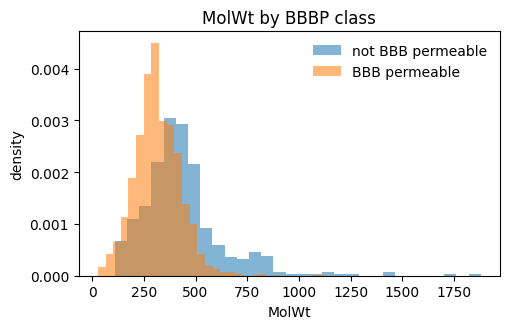

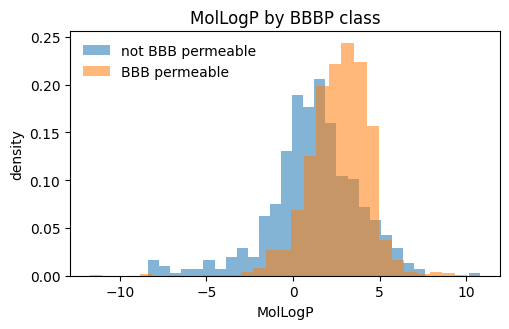

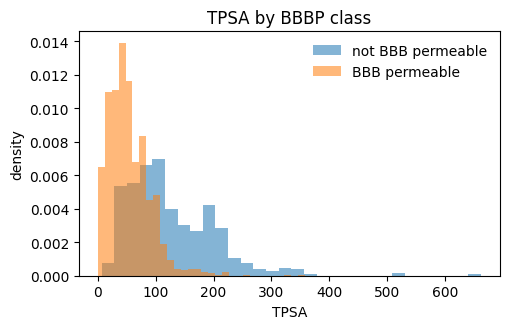

In [8]:
# Quick look at descriptor distributions by class

for feature in ["MolWt", "MolLogP", "TPSA",]:
    # Create a new figure for this descriptor.
    fig, ax = plt.subplots(figsize=(5.2, 3.4))
    # Plot the distribution of this descriptor for BBB-nonpermeable molecules.
    # density=True normalizes the histogram so that groups of different sizes can be compared by distribution shape rather than raw count.
    ax.hist(
        model_df.loc[model_df["p_np"] == 0, feature],
        bins=30,
        alpha=0.55,
        density=True,
        label="not BBB permeable",
    )
    # Plot the distribution of this descriptor for BBB-permeable molecules.
    ax.hist(
        model_df.loc[model_df["p_np"] == 1, feature],
        bins=30,
        alpha=0.55,
        density=True,
        label="BBB permeable",
    )
    ax.set_xlabel(feature)
    ax.set_ylabel("density")
    ax.legend(frameon=False)
    ax.set_title(f"{feature} by BBBP class")
    plt.tight_layout()
    plt.show()

The class-conditional means provide a first sanity check. Do the data agree with our chemical intuition?

## 3. Train/test split

We will use a stratified train/test split so that both classes are represented in each split. In the process, we remove any rows containing missing data. Alternatively, at this stage we could work imputation into our pipeline, but that is outside the scope of today's tutorial.

Because many interpretability methods are sensitive to the dataset being explained, we will usually compute explanations on the held-out test set.

In [9]:
# Clean once, before constructing X and y.
#
# We require:
#   1. a valid BBBP label, p_np
#   2. valid values for all candidate descriptors

required_cols = ["p_np", *candidate_feature_cols]

model_df_clean = (
    model_df
    .dropna(subset=required_cols)
    .copy()
)

print("Rows removed because of missing labels or descriptors:")
print(len(model_df) - len(model_df_clean))


# Construct the full candidate feature matrix.
# This includes all descriptors before correlation filtering.
X_all = model_df_clean[candidate_feature_cols].copy()


# Construct the target vector.
y = model_df_clean["p_np"].astype(int).to_numpy()


# Store original row indices so that later explanations can be traced
# back to molecule names, SMILES strings, and RDKit Mol objects.
indices = model_df_clean.index.to_numpy()


# Split the full candidate descriptor matrix into train and test sets.
#
# We do the split before feature filtering so that the correlation filter
# can be fit using only the training set.
X_train_all, X_test_all, y_train, y_test, idx_train, idx_test = train_test_split(
    X_all,
    y,
    indices,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Candidate features before filtering:", len(candidate_feature_cols))
print("Remaining missing values in X_train_all:", X_train_all.isna().sum().sum())

Rows removed because of missing labels or descriptors:
0
Candidate features before filtering: 31
Remaining missing values in X_train_all: 0


Including correlated descriptors is not necessarily bad for prediction, but it can make interpretation harder. If two features contain similar information, a model may split importance across them or assign coefficients with opposite signs.

To make interpretation cleaner, we remove one descriptor from each highly correlated pair. The correlation filter is fit using only the training set, and then the same selected features are used for both the training and test sets. While we're at it, let's also check for and remove low variance features.

In [10]:
# Correlation threshold for deciding that two descriptors are redundant.
CORR_THRESHOLD = 0.85

# Features with training-set variance at or below this value are removed.
LOW_VARIANCE_THRESHOLD = 0.01

# We use a priority list to decide which descriptor to keep when two descriptors are highly correlated.
#
# Earlier descriptors in this list are preferred simply because they are especially common or interpretable for BBBP.
descriptor_priority = [
    "MolWt",
    "MolLogP",
    "TPSA",
    "NumHDonors",
    "NumHAcceptors",
    "NumRotatableBonds",
    "RingCount",
    "AromaticRingCount",
    "FractionCSP3",
    "FormalCharge",
    "NumHeteroatoms",
    "LabuteASA",
    "MolMR",
    "BertzCT",
    "BalabanJ",
    "Kappa1",
    "Kappa2",
    "Kappa3",
    "Chi0",
    "Chi1",
]


def remove_correlated_features(
    X,
    threshold=0.85,
    priority=None,
    variance_threshold=0.01,
):
    """
    Remove low-variance features and one feature from each highly
    correlated feature pair.

    All statistics should be calculated using training data only.

    Parameters
    ----------
    X:
        Training feature matrix as a pandas DataFrame.

    threshold:
        Absolute Pearson correlation threshold.
        If |correlation| >= threshold, two features are considered redundant.

    priority:
        Ordered list of feature names.
        Earlier features are preferred when deciding which feature to keep.

    variance_threshold:
        Features with variance <= this value are removed before
        correlation filtering.

    Returns
    -------
    selected_features:
        List of retained feature names.

    dropped_features:
        Set of all removed features.

    low_variance_features:
        List of features removed because of low variance.

    feature_variances:
        Series containing the training-set variance of each feature.

    decisions_df:
        DataFrame describing which correlated pairs were found and which feature was removed.

    corr_abs:
        Absolute correlation matrix after low-variance features were removed.
    """

    # If no priority list is provided, use an empty list.
    if priority is None:
        priority = []

    # Calculate population variance for each feature.
    feature_variances = X.var(axis=0, ddof=0)

    # Identify low-variance features
    low_variance_features = feature_variances[
        feature_variances <= variance_threshold
    ].index.tolist()

    # Remove low-variance features before computing correlations
    X_filtered = X.drop(columns=low_variance_features)

    # Compute the absolute Pearson correlation matrix.
    corr_abs = X_filtered.corr().abs()

    # Keep only the upper triangle of the correlation matrix and create a dictionary mapping each priority feature to its rank.
    upper = corr_abs.where(
        np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
    )
    priority_rank = {
        feature: rank
        for rank, feature in enumerate(priority)
    }

    def get_rank(feature):
        """
        Get the priority rank for a feature.

        Features listed in descriptor_priority are ranked by their position in that list.
        Features not listed are ranked after listed features, in their original column order.
        """
        if feature in priority_rank:
            return priority_rank[feature]

        return len(priority_rank) + list(X_filtered.columns).index(feature)

    # Start the dropped-features set with low-variance features.
    dropped_features = set(low_variance_features)

    decisions = []
    correlated_pairs = []

    for feature_1 in upper.index:
        for feature_2 in upper.columns:
            # Get the absolute correlation between this feature pair.
            corr_value = upper.loc[feature_1, feature_2]
            # If the correlation is high enough, mark this pair as redundant.
            if pd.notna(corr_value) and corr_value >= threshold:
                correlated_pairs.append(
                    (feature_1, feature_2, corr_value)
                )
    # Sort correlated pairs from strongest to weakest correlation.
    correlated_pairs = sorted(
        correlated_pairs,
        key=lambda pair: pair[2],
        reverse=True,
    )
    # For each highly correlated pair, remove one feature.
    for feature_1, feature_2, corr_value in correlated_pairs:
        if (
            feature_1 in dropped_features
            or feature_2 in dropped_features
        ):
            continue
        # Keep the higher-priority feature and drop the lower-priority one.
        if get_rank(feature_1) <= get_rank(feature_2):
            kept = feature_1
            dropped = feature_2
        else:
            kept = feature_2
            dropped = feature_1

        dropped_features.add(dropped)

        decisions.append(
            {
                "feature kept": kept,
                "feature removed": dropped,
                "absolute correlation": corr_value,
            }
        )
    # Final selected features are all original features that were not removed.
    selected_features = [
        feature
        for feature in X.columns
        if feature not in dropped_features
    ]

    decisions_df = pd.DataFrame(decisions)

    return (
        selected_features,
        dropped_features,
        low_variance_features,
        feature_variances,
        decisions_df,
        corr_abs,
    )

(
    feature_cols,
    dropped_features,
    low_variance_features,
    feature_variances,
    corr_decisions,
    corr_abs,
) = remove_correlated_features(
    X_train_all,
    threshold=CORR_THRESHOLD,
    priority=descriptor_priority,
    variance_threshold=LOW_VARIANCE_THRESHOLD,
)

print("Candidate features:   ", len(candidate_feature_cols))
print("Selected features:    ", len(feature_cols))
print("Low-variance removed: ", len(low_variance_features))
print("Total removed:        ", len(dropped_features))

print("\nLow-variance features:")
for feature in low_variance_features:
    print(f"{feature}: variance={feature_variances[feature]:.6g}")

print("\nSelected features:")
print(feature_cols)

print("\nAll removed features:")
print(sorted(dropped_features))

display(corr_decisions.round(3))

Candidate features:    31
Selected features:     14
Low-variance removed:  1
Total removed:         17

Low-variance features:
FormalCharge: variance=0.00719382

Selected features:
['MolWt', 'MolLogP', 'TPSA', 'NumRotatableBonds', 'FractionCSP3', 'RingCount', 'AromaticRingCount', 'AliphaticRingCount', 'NumAromaticHeterocycles', 'NumAromaticCarbocycles', 'NumSaturatedHeterocycles', 'NumSaturatedCarbocycles', 'BalabanJ', 'Kappa3']

All removed features:
['Chi0', 'Chi1', 'ExactMolWt', 'FormalCharge', 'HeavyAtomCount', 'HeavyAtomMolWt', 'Kappa1', 'Kappa2', 'LabuteASA', 'MolMR', 'NHOHCount', 'NOCount', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumValenceElectrons', 'SaturatedRingCount']


,feature kept,feature removed,absolute correlation
0,MolWt,ExactMolWt,1.000
1,MolWt,HeavyAtomMolWt,0.999
2,Chi1,HeavyAtomCount,0.999
3,Chi0,NumValenceElectrons,0.998
4,LabuteASA,Chi1,0.994
5,MolWt,LabuteASA,0.993
6,MolWt,Chi0,0.987
7,MolWt,Kappa1,0.981
8,MolWt,MolMR,0.973
9,NumHDonors,NHOHCount,0.967


In [11]:
# Create the final training and test matrices using only the selected features.
#
# From this point onward:
#   X_train and X_test contain the correlation-filtered descriptor set.
#   feature_cols contains the final model input feature names.
X_train = X_train_all[feature_cols].copy()
X_test = X_test_all[feature_cols].copy()


print("Final X_train shape:", X_train.shape)
print("Final X_test shape: ", X_test.shape)
print("Remaining missing values:", X_train.isna().sum().sum())

Final X_train shape: (1529, 14)
Final X_test shape:  (510, 14)
Remaining missing values: 0


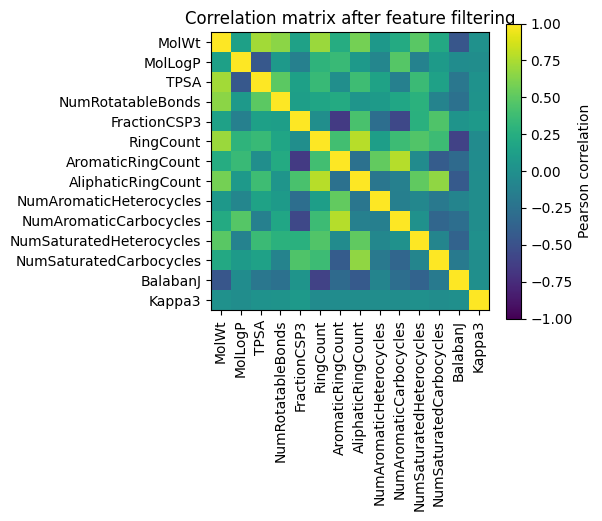

In [12]:
# Check the descriptor correlations after filtering.
#
# Ideally, there should be fewer very bright/yellow off-diagonal entries than in the original full descriptor matrix.
corr_filtered = X_train.corr()

fig, ax = plt.subplots(figsize=(6.0, 5.2))

im = ax.imshow(corr_filtered, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(feature_cols)))
ax.set_yticks(np.arange(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=90)
ax.set_yticklabels(feature_cols)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Pearson correlation")

ax.set_title("Correlation matrix after feature filtering")

plt.tight_layout()
plt.show()

The following helper function will allow us to quickly and easily evaluate classifiers using several metrics.

In [13]:
def evaluate_classifier(model, X_eval, y_eval, name="model"):
    """
    Evaluate a trained classification model and plot its ROC curve.

    Parameters
    ----------
    model:
        A trained scikit-learn classifier.

    X_eval:
        Feature matrix used for evaluation.
        This is often X_test, but could also be X_train.

    y_eval:
        True class labels for X_eval.

    name:
        Name of the model, used for printing results and plot title.

    Returns
    -------
    metrics:
        Dictionary containing classification performance metrics.
    """

    y_pred = model.predict(X_eval)

    # Get a continuous model score for the positive class.
    # ROC-AUC and ROC curves require scores.
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_eval)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_eval)
    else:
        y_score = y_pred

    # Compute classification metrics.
    metrics = {
        "accuracy": accuracy_score(y_eval, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_eval, y_pred),
        "roc_auc": roc_auc_score(y_eval, y_score),
    }

    # Print the results.
    print(name)
    print("-" * len(name))
    for key, value in metrics.items():
        print(f"{key:20s}: {value:.3f}")

    # Compute and plot the ROC curve.
    false_positive_rate, true_positive_rate, thresholds = roc_curve(
        y_eval,
        y_score,
    )

    fig, ax = plt.subplots(figsize=(5.2, 4.0))

    ax.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"ROC-AUC = {metrics['roc_auc']:.3f}",
    )
    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
        label="random ranking",
    )

    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"ROC curve: {name}")
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()

    return metrics

## 4. Interpretability by design: logistic regression

A logistic regression model is one of the simplest models for binary classification. It is often considered **interpretable by design** because the model has one coefficient for each input feature. If the features are chemically meaningful, then the coefficients can often be interpreted chemically.

The model takes molecular descriptors as input, such as molecular weight, MolLogP, TPSA, hydrogen-bond donors, and hydrogen-bond acceptors. It then predicts the probability that a molecule belongs to the positive class:

$$
P(y = 1)
=
P(\mathrm{BBB\ permeable})
$$

Logistic regression does this in two steps.

First, it computes a linear score:

$$
\eta
=
\beta_0 + \sum_j \beta_j x_j
$$

where:

- $\eta$ is the model's linear score
- $\beta_0$ is the intercept
- $\beta_j$ is the coefficient for feature $j$
- $x_j$ is the value of feature $j$

Then, it converts this score into a probability using the logistic sigmoid function:

$$
P(y = 1)
=
\frac{1}{1 + e^{-\eta}}
$$

The sigmoid function maps any real-valued score onto a number between 0 and 1, so it can be interpreted as a probability.

### Log-odds interpretation

Logistic regression is called "logistic" because it models the **log-odds** of the positive class as a linear function of the features.

The odds of BBB permeability are:

$$
\mathrm{odds}
=
\frac{P(y = 1)}{1 - P(y = 1)}
$$

The log-odds are:

$$
\log
\left(
\frac{P(y = 1)}{1 - P(y = 1)}
\right)
$$

Logistic regression assumes:

$$
\log
\left(
\frac{P(y = 1)}{1 - P(y = 1)}
\right)
=
\beta_0 + \sum_j \beta_j x_j
$$

This means each coefficient describes how the log-odds of BBB permeability change when that descriptor increases.

#### Exercise 1 — Train and evaluate a logistic regression model

In this exercise, you will train a standardized logistic regression model to predict BBB permeability from molecular descriptors.

Your tasks:

1. Create a scikit-learn pipeline ([`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html)) with two steps:
   - [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
   - [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

2. Fit the model using the training data.

3. Evaluate the trained model on the held-out test set using `evaluate_classifier`.

4. Look at the test-set metrics and ROC curve. Does logistic regression appear to perform better than random guessing?

Standardized logistic regression
--------------------------------
accuracy            : 0.841
balanced_accuracy   : 0.712
roc_auc             : 0.838


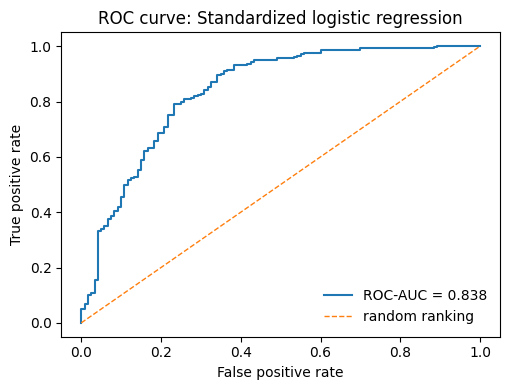

In [14]:
# Exercise: Train and evaluate standardized logistic regression

# TODO 1:
# Create a pipeline that standardizes the descriptors and then fits a logistic regression classifier.
logreg_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
    ),
)

# TODO 2:
# Fit the pipeline using the training data.
logreg_model.fit(X_train, y_train)

# TODO 3:
# Evaluate the trained model on the held-out test set using evaluate_classifier.
logreg_metrics = evaluate_classifier(
    logreg_model,
    X_test,
    y_test,
    name="Standardized logistic regression",
)

,standardized coefficient
TPSA,-1.578265
NumSaturatedHeterocycles,-0.501365
MolWt,-0.440372
NumSaturatedCarbocycles,-0.263726
NumAromaticCarbocycles,-0.110508
AromaticRingCount,-0.106273
NumAromaticHeterocycles,-0.017477
MolLogP,0.060308
BalabanJ,0.080358
FractionCSP3,0.087928


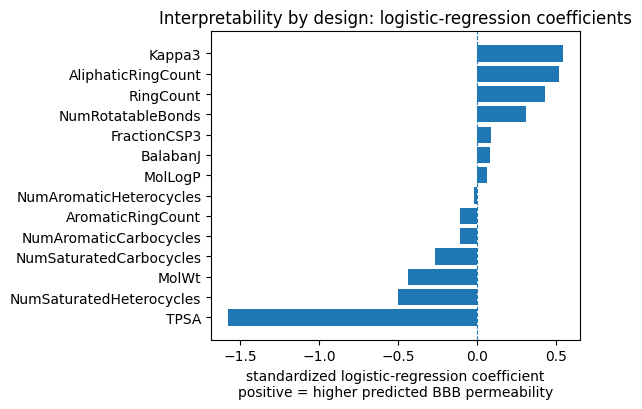

In [15]:
# Extract the fitted logistic-regression coefficients from the pipeline.
#
# named_steps["logisticregression"] accesses the trained logistic regression model.
#.coef_[0] extracts the coefficient vector for the positive class.

logreg_coef = pd.Series(
    logreg_model.named_steps["logisticregression"].coef_[0],
    index=feature_cols,
).sort_values()

# Display the coefficients as a one-column table and plot the results.
display(logreg_coef.rename("standardized coefficient").to_frame())
fig, ax = plt.subplots(figsize=(6.0, 4.2))
ax.barh(logreg_coef.index, logreg_coef.values)
ax.axvline(0, linewidth=0.8, linestyle="--")
ax.set_xlabel("standardized logistic-regression coefficient\npositive = higher predicted BBB permeability")
ax.set_title("Interpretability by design: logistic-regression coefficients")
plt.tight_layout()
plt.show()

Pause to consider the results (and see the answer key for some of my thoughts).

The logistic-regression coefficients show several chemically reasonable trends. TPSA has the largest negative coefficient, indicating that higher polar surface area strongly decreases the predicted probability of BBB permeability. Molecular weight is also negative, suggesting that larger molecules are less likely to be predicted as BBB permeable. MolLogP is positive, consistent with the idea that lipophilicity can favor membrane partitioning, although its effect is smaller than the TPSA effect in this model.

Several ring and shape descriptors, including Kappa3, AliphaticRingCount, RingCount, FractionCSP3, and BalabanJ, have positive coefficients. This suggests that the model associates some ring-rich or more three-dimensional structures with higher BBB permeability. However, these descriptors are less directly interpretable than TPSA or MolWt, so they should be interpreted cautiously.

Overall, the model appears to learn a clear polarity penalty and a weaker size penalty, along with more subtle structure/shape effects. These coefficients describe how the model uses the selected descriptors; they should not be interpreted as proof that each descriptor has an isolated causal effect on BBB permeability.

## 5. Training a GB tree model

Next, let's train a gradient boosted tree classifier. These models may perform better than something simple like logistic regression but are less directly interpretable. We will therefore use post-hoc methods to explain their behavior.

Here we also include some hyperparameter tuning via cross-validation on the training set. This allows us to choose a model that balances flexibility and generalization without using the test set during model selection. After the best hyperparameters are selected, we evaluate the optimized model once on the held-out test set.

For the sake of today's tutorial, I've commented out the hyperparameter grid search (as it is somewhat computationally expensive) and built a model using the results of a rather coarse grid search that I conducted myself. As an optional exercise, feel free to uncomment the hyperparameter optimization code and attempt to improve model performance even more! What strategies could we use to make this process more efficient?

In [16]:
''' # Define the base gradient boosting classifier.
gb_base_model = GradientBoostingClassifier(
    random_state=RANDOM_STATE,
)

# Define the hyperparameter grid to search.
#
# n_estimators:
#   Number of boosting stages, i.e., number of trees.
#   More trees can improve performance but may overfit.
#
# learning_rate:
#   How strongly each new tree contributes to the final model.
#   Lower learning rates often require more trees.
#
# max_depth:
#   Maximum depth of each individual tree.
#   Shallow trees capture simpler interactions; deeper trees capture more complex interactions.
#
# min_samples_leaf:
#   Minimum number of samples required in each leaf.
#   Larger values make the model smoother and can reduce overfitting.
#
# subsample:
#   Fraction of training samples used to fit each tree.
#   Values below 1.0 introduce stochasticity and can reduce overfitting.
param_grid = {
    "n_estimators": [100, 200,500],
    "learning_rate": [0.01,0.05, 0.1],
    "max_depth": [8,10,12],
    "min_samples_leaf": [1,3],
    "subsample": [0.4,0.5,0.6],
}


# Use stratified cross-validation so that each fold has approximately the same fraction of BBB-permeable and BBB-nonpermeable molecules.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)


# Set up the grid search.
gb_search = GridSearchCV(
    estimator=gb_base_model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)


# Run the hyperparameter search on the training set.
gb_search.fit(X_train, y_train)


# Print the best cross-validated score and best hyperparameters.
print("Best cross-validated ROC-AUC:")
print(f"{gb_search.best_score_:.3f}")

print("\nBest hyperparameters:")
print(gb_search.best_params_)


# Extract the best fitted gradient boosted tree model.
#
# Because refit=True, this model has already been retrained on the full
# training set using the best hyperparameters.
gb_model = gb_search.best_estimator_


# Evaluate the optimized model once on the held-out test set.
gb_metrics = evaluate_classifier(
    gb_model,
    X_test,
    y_test,
    name="Optimized gradient boosted trees",
) '''

' # Define the base gradient boosting classifier.\ngb_base_model = GradientBoostingClassifier(\n    random_state=RANDOM_STATE,\n)\n\n# Define the hyperparameter grid to search.\n#\n# n_estimators:\n#   Number of boosting stages, i.e., number of trees.\n#   More trees can improve performance but may overfit.\n#\n# learning_rate:\n#   How strongly each new tree contributes to the final model.\n#   Lower learning rates often require more trees.\n#\n# max_depth:\n#   Maximum depth of each individual tree.\n#   Shallow trees capture simpler interactions; deeper trees capture more complex interactions.\n#\n# min_samples_leaf:\n#   Minimum number of samples required in each leaf.\n#   Larger values make the model smoother and can reduce overfitting.\n#\n# subsample:\n#   Fraction of training samples used to fit each tree.\n#   Values below 1.0 introduce stochasticity and can reduce overfitting.\nparam_grid = {\n    "n_estimators": [100, 200,500],\n    "learning_rate": [0.01,0.05, 0.1],\n    "

Gradient boosted trees
----------------------
accuracy            : 0.892
balanced_accuracy   : 0.817
roc_auc             : 0.883


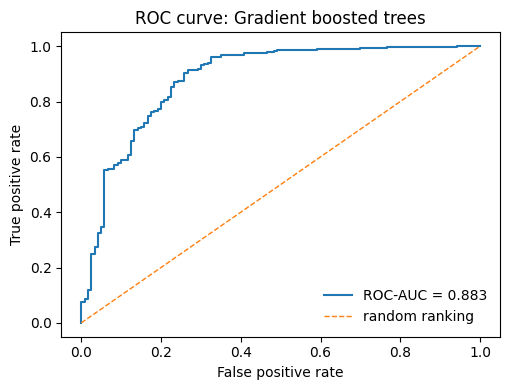

In [17]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=10,
    min_samples_leaf=1,
    subsample=0.5,
    random_state=RANDOM_STATE,
)

# Fit the model on the training set.
gb_model.fit(X_train, y_train)

# Evaluate the trained model once on the held-out test set.
gb_metrics = evaluate_classifier(
    gb_model,
    X_test,
    y_test,
    name="Gradient boosted trees",
)

Compare the logistic regression and gradient boosted tree models. Consider the following:

1. Which model performs best? (What performance metric(s) should we use?)
2. Which model is easiest to explain directly?
3. Which model would you choose for prediction? Which would you choose for explanation?

## 6. Model-agnostic global interpretability: permutation importance

Next, we should analyze model performance using the post-hoc methods we learned about.

We begin with permutation importance. Recall that permutation importance operates by iterating through every feature, randomly shuffling feature values, and comparing model predictions to the pre-shuffled predictions.

#### Exercise 2 — Compute permutation importance

In this exercise, you will write a helper function to compute permutation importance for a trained model.

Your tasks:

1. Use [`permutation_importance`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html) to compute feature importances for a trained model.
2. Store the mean importance value for each descriptor.
3. Store the standard deviation of the importance value for each descriptor.
4. Return both objects from the function.

In [18]:
def compute_permutation_importance(
    model,
    X_eval,
    y_eval,
    feature_cols,
    scoring="roc_auc",
    n_repeats=50,
):
    """
    Compute permutation importance for a trained model.

    Permutation importance measures how much model performance decreases
    when each feature is randomly shuffled.

    Parameters
    ----------
    model:
        Trained model to explain.

    X_eval:
        Feature matrix used for evaluating importance.
        This is often X_test.

    y_eval:
        True labels for X_eval.

    feature_cols:
        Names of the molecular descriptors.

    scoring:
        Performance metric used to measure importance.

    n_repeats:
        Number of times to shuffle each feature.

    Returns
    -------
    importance:
        Mean decrease in model performance after shuffling each feature.

    importance_std:
        Standard deviation of the importance values across repeats.
    """

    # TODO 1:
    # Use sklearn.inspection.permutation_importance to compute permutation importance for the trained model.
    # Include all parameters that appear in the call to permutation_importance except for feature_cols.
    result = permutation_importance(
        model,
        X_eval,
        y_eval,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    # TODO 2:
    # Create a pandas Series containing the mean importance value for each feature.
    # Include index=feature_cols.
    importance = pd.Series(
        result.importances_mean,
        index=feature_cols,
    )
    # TODO 3:
    # Create a pandas Series containing the standard deviation of the importance value for each feature.
    # Include index=feature_cols.
    importance_std = pd.Series(
        result.importances_std,
        index=feature_cols,
    )
    return importance, importance_std

# Compute, sort, and display permutation importance for the gradient boosted tree model.
gb_perm, gb_perm_std = compute_permutation_importance(
    gb_model,
    X_test,
    y_test,
    feature_cols,
)

perm_df = pd.DataFrame({
    "GB permutation": gb_perm,
    "GB std": gb_perm_std,
}).sort_values("GB permutation", ascending=False)

display(perm_df)

,GB permutation,GB std
TPSA,0.165426,0.020134
FractionCSP3,0.016250,0.004442
MolLogP,0.013949,0.005733
BalabanJ,0.012566,0.004223
MolWt,0.010955,0.004762
NumSaturatedHeterocycles,0.010365,0.001934
NumRotatableBonds,0.008186,0.004216
NumSaturatedCarbocycles,0.006292,0.003719
AliphaticRingCount,0.004362,0.001953
Kappa3,0.004033,0.004952


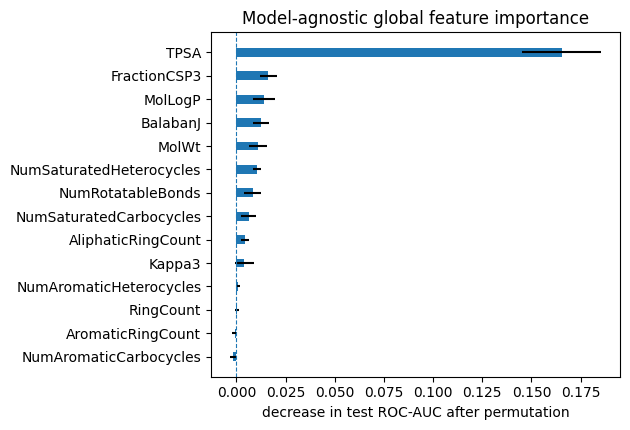

In [19]:
# Plot the results
fig, ax = plt.subplots(figsize=(6.4, 4.4))

plot_df = perm_df.sort_values("GB permutation")
y_pos = np.arange(len(plot_df))
bar_width = 0.38

ax.barh(
    y_pos,
    plot_df["GB permutation"],
    xerr=plot_df["GB std"],
    height=bar_width,
    )

ax.axvline(0, linewidth=0.8, linestyle="--")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df.index)
ax.set_xlabel("decrease in test ROC-AUC after permutation")
ax.set_title("Model-agnostic global feature importance")

plt.tight_layout()
plt.show()

Pause to consider the results (and see the answer key for some of my thoughts). What does permutation importance tell us about our model?

The permutation-importance plot shows that TPSA is by far the most important descriptor for the gradient boosted tree model. Randomly shuffling TPSA causes a large decrease in test ROC-AUC, indicating that the model relies strongly on polar surface area to distinguish BBB-permeable from BBB-nonpermeable molecules.

Other descriptors, including MolLogP, MolWt, BalabanJ, FractionCSP3, and several ring-related descriptors, have much smaller importance values. These features may contribute to the model, but their effects are secondary compared with TPSA. Several descriptors have importance values near zero, meaning that shuffling them does not substantially affect test-set performance. We could therefore consider removing them from our pipeline entirely.

## 7. ICE and PDP: how does a feature affect predictions?

Permutation importance tells us which features matter, but not how they affect predictions. To dig deeper, we turn to ICE and PDP.

For sample $i$, feature $j$, and chosen value $z$, the ICE value is:

$$
\mathrm{ICE}_{i,j}(z) = f(z, x_{i,-j})
$$

The PDP is the average of the ICE curves:

$$
\mathrm{PD}_{j}(z) =
\frac{1}{n}\sum_i f(z, x_{i,-j})
$$

For classification, we plot the predicted probability of the positive class:

$$
P(\mathrm{BBB\ permeable}\mid x)
$$

#### Exercise 3 — Interpret the model with ICE and PDP plots

In this exercise, you will use ICE and PDP plots to understand how the gradient boosted tree model uses selected molecular descriptors for individual molecules and on average.

You will use  from scikit-learn.

Your tasks:

1. Choose a small set of descriptors to visualize.
2. Generate ICE/PDP plots for each descriptor using [`PartialDependenceDisplay.from_estimator`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.PartialDependenceDisplay.html).
3. Generate a two-feature PDP for for a pair of descriptors.
4. Interpret how features affect individual and average predictions of the GB tree model.

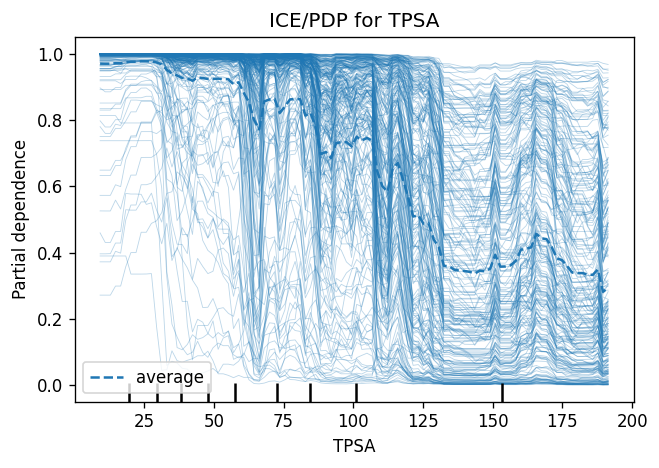

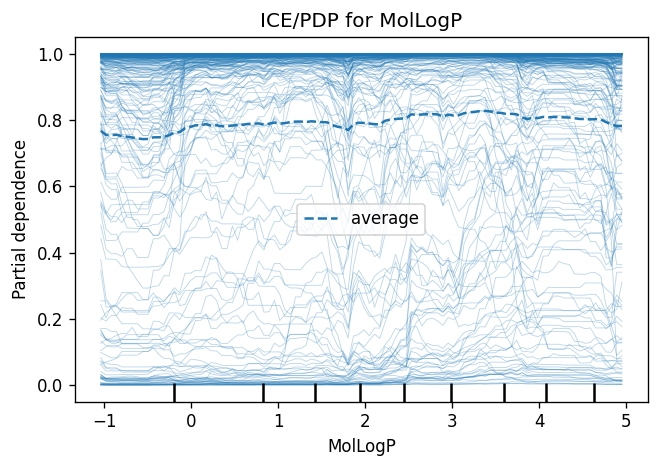

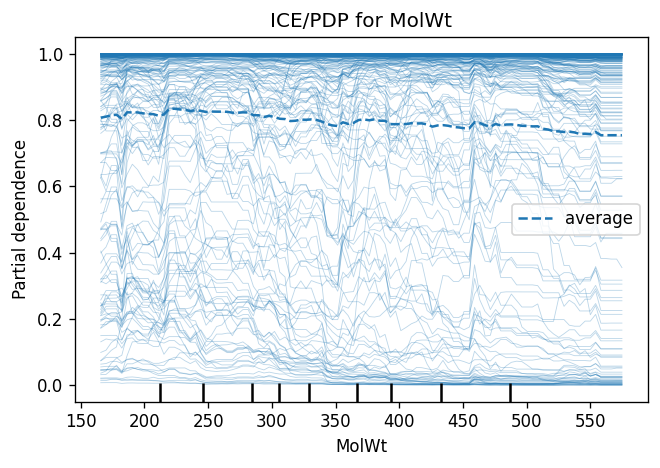

In [20]:
# TODO 1:
# Choose descriptors to visualize.
#
# Hint: Good starting choices are features that were important in previous analyses.
features_to_plot = ["TPSA", "MolLogP", "MolWt"]

# TODO 2:
# Loop over the selected descriptors and make one ICE/PD plot per descriptor.
for feature in features_to_plot:
    # (Optional) Temporarily increase figure resolution for these plots.
    with plt.rc_context({"figure.dpi": 120}):
        fig, ax = plt.subplots(figsize=(5.6, 4.0))

        PartialDependenceDisplay.from_estimator(
            gb_model,
            X_test,
            features=[feature],
            kind="both",
            random_state=RANDOM_STATE,
            ax=ax,
            subsample=0.5
        )

        ax.set_title(f"ICE/PDP for {feature}")
        plt.tight_layout()
        plt.show()

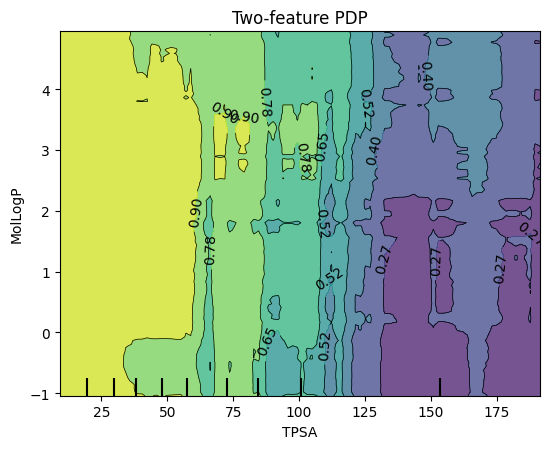

In [21]:
# Two-feature PDP to inspect interactions
fig, ax = plt.subplots(figsize=(5.6, 4.6))

# TODO 3:
# Generate a two-feature PDP.
PartialDependenceDisplay.from_estimator(
    gb_model,
    X_test,
    features=[("TPSA","MolLogP")],
    method="brute",
    response_method="predict_proba",
    ax=ax,
    )

ax.set_title("Two-feature PDP")
plt.tight_layout()
plt.show()

Pause to consider the results (and see the answer key for some of my thoughts).

For each plot, consider:

- Are ICE curves mostly parallel, or do different molecules behave differently?
- Are there sparse regions where the model is extrapolating?
- Are the feature combinations chemically plausible?

The ICE/PDP plots reaffirm that the gradient boosted tree model relies strongly on TPSA. In particular, as TPSA increases, the average predicted probability of BBB permeability decreases substantially. This is chemically reasonable because high polar surface area makes passive membrane crossing less favorable.

MolLogP has a much weaker average effect. The model predicts slightly higher BBB permeability for more lipophilic molecules, but the effect is modest and highly molecule-dependent. MolWt also has a weak negative effect, consistent with larger molecules being less likely to cross the BBB.

## 8. SHAP: global/local additive attributions

SHAP explains a prediction by decomposing it into feature attributions.

For one molecule,

$$
f(x_i) = \phi_0 + \sum_j \phi_{i,j}
$$

where:

- $\phi_0$: baseline model output
- $\phi_{i,j}$: SHAP value for feature $j$ in molecule $i$

For this classifier, we will explain the predicted probability of BBB permeability. Positive SHAP values push the prediction toward BBB permeable; negative SHAP values push the prediction toward not BBB permeable.

Calculating SHAP values on `X_test` is usually more meaningful than explaining on `X_train`, because the test set better represents model behavior on unseen data. However, this is not strictly required, and depends on the goal. If the goal is debugging a model or even explaining future predictions, it is common to also compute SHAP values on the training set and/or new candidate molecules.

In [22]:
# A bit of housekeeping: later in the notebook we will compare individual SHAP and LIME explanations, and here ensure that we use the same molecule when we use the same sample_idx.
#
# To make that reliable, we create:
#   X_test_explain : test-set descriptors with a clean 0, 1, 2, ... index
#   test_info      : molecule metadata in exactly the same row order
#
# From this point on:
#   sample_idx = row position in X_test_explain and test_info

X_test_explain = X_test[feature_cols].copy().reset_index(drop=True)

test_info = (
    model_df
    .loc[idx_test, ["name", "smiles", "p_np"] + feature_cols]
    .copy()
    .reset_index()
    .rename(columns={"index": "model_df_index"})
)

# Add the positional test-set index explicitly.
test_info.insert(0, "sample_idx", np.arange(len(test_info)))

# Add the true labels from y_test explicitly.
test_info["y_test"] = y_test

# Sanity checks:
# The number of rows should match across all aligned test-set objects.
assert len(X_test_explain) == len(test_info) == len(y_test)

display(test_info.head())

,sample_idx,model_df_index,name,smiles,p_np,MolWt,MolLogP,TPSA,NumRotatableBonds,FractionCSP3,RingCount,AromaticRingCount,AliphaticRingCount,NumAromaticHeterocycles,NumAromaticCarbocycles,NumSaturatedHeterocycles,NumSaturatedCarbocycles,BalabanJ,Kappa3,y_test
0,0,1882,lobeline,C3=C(C(CC2N(C(CC(C1=CC=CC=C1)=O)CCC2)C)O)C=CC=C3,1,337.463,4.2360,40.54,6,0.409091,3,2,1,0,2,1,0,1.606570,4.559099,1
1,1,1430,ocinaplon,C1=N[N]3C(=C1C(C2=NC=CC=C2)=O)N=CC=C3C4=CC=NC=C4,1,301.309,2.4173,73.04,3,0.000000,4,4,0,4,0,0,0,1.871130,2.259128,1
2,2,1714,brallobarbital,C(C1(C(NC(=O)NC1=O)=O)CC=C)C(=C)Br,1,287.113,1.2136,75.27,4,0.300000,1,0,1,0,0,1,0,3.102380,2.213749,1
3,3,1969,prednisolone-hemisuccinate,[C@]14([C@@](C(=O)COC(CCC(=O)[O-])=O)(CC[C@H]1...,1,482.505,-2.3574,141.03,6,0.680000,4,0,4,0,0,0,3,0.000003,4.256812,1
4,4,543,GR94839_I,c1(CC(N2[C@H](CN(CC2)C(=O)C)C[N@]2CC[C@H](O)C2...,0,407.536,0.0924,81.16,5,0.600000,3,1,2,0,1,2,0,1.676990,5.182335,0


#### Exercise 4 — Compute and visualize SHAP values

In this exercise, you will compute SHAP values for the gradient boosted tree model and visualize them with a beeswarm plot.

Your tasks:

1. Create a model-agnostic SHAP explainer using [`shap.Explainer`](https://shap.readthedocs.io/en/latest/generated/shap.Explainer.html).
2. Compute SHAP values for a subset of test molecules.
3. Make a SHAP beeswarm plot using [`shap.plots.beeswarm`](https://shap.readthedocs.io/en/latest/generated/shap.plots.beeswarm.html).

In [23]:
# SHAP needs a background or reference dataset to define a baseline prediction.
# We use a sample from the training set because it represents the distribution
# the model learned from.
background = shap.sample(
    X_train[feature_cols],
    nsamples=min(100, len(X_train)),
    random_state=RANDOM_STATE,
)


def gb_predict_proba_positive(X_array):
    """
    Prediction function for SHAP.

    SHAP passes NumPy arrays, so we convert them back into DataFrames
    with the correct feature names before calling the model.
    """

    X_df = pd.DataFrame(
        X_array,
        columns=feature_cols,
    )

    # Return predicted probability of class 1:
    #   class 1 = BBB permeable
    return gb_model.predict_proba(X_df)[:, 1]


# TODO 1:
# Create a model-agnostic SHAP explainer.
explainer = shap.Explainer(
    gb_predict_proba_positive,
    background,
)


# To keep the tutorial responsive, explain only the first N test molecules.
N_SHAP = min(150, len(X_test_explain))

# TODO 2:
# Compute SHAP values for the test-set subset.
X_shap_subset = X_test_explain.iloc[:N_SHAP].copy()
shap_values = explainer(X_shap_subset)

print("SHAP values shape:", shap_values.values.shape)

PermutationExplainer explainer: 151it [01:19,  1.76it/s]

SHAP values shape: (150, 14)


,mean absolute SHAP
NumAromaticHeterocycles,0.003480
NumAromaticCarbocycles,0.004677
AromaticRingCount,0.005402
RingCount,0.005815
NumSaturatedCarbocycles,0.005921
AliphaticRingCount,0.014191
NumSaturatedHeterocycles,0.015929
NumRotatableBonds,0.017785
BalabanJ,0.023673
MolWt,0.026822


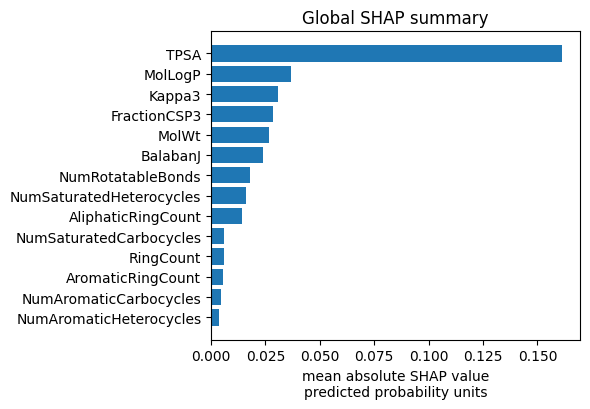

In [24]:
# Mean absolute SHAP values give a global summary.
# shap_values.values contains the SHAP values for many molecules.
#
# Each entry tells us how much that feature pushed the model prediction up or down for one molecule.
#
# Taking the absolute value removes direction.
#
# Then .mean(axis=0) averages across molecules.
# The result is one global importance value per feature.

shap_importance = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=feature_cols,
).sort_values()

# Display and plot the results.

display(shap_importance.rename("mean absolute SHAP").to_frame())

fig, ax = plt.subplots(figsize=(6.0, 4.2))

ax.barh(shap_importance.index, shap_importance.values)
ax.set_xlabel("mean absolute SHAP value\npredicted probability units")
ax.set_title("Global SHAP summary")

plt.tight_layout()
plt.show()

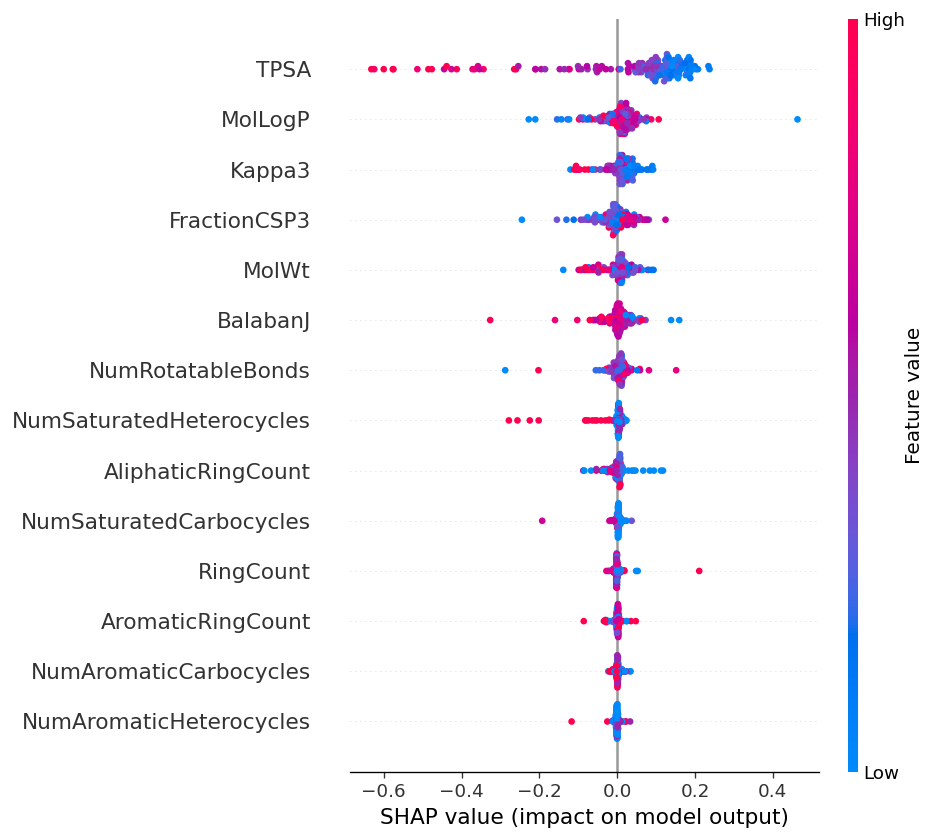

In [25]:
# SHAP beeswarm plot

with plt.rc_context({"figure.dpi": 120}):
    # TODO 3:
    # Make a SHAP beeswarm plot.
    shap.plots.beeswarm(
        shap_values,
        max_display=len(feature_cols),
        show=False,
    )
    plt.tight_layout()
    plt.show()

Pause to consider the results (and see the answer key for some of my thoughts).

The SHAP beeswarm plot shows that TPSA is the dominant feature in the gradient boosted tree model. High TPSA values have large negative SHAP values, meaning they strongly decrease the predicted probability of BBB permeability. Low TPSA values tend to have positive SHAP values, meaning they increase the predicted probability of BBB permeability. Note that negative TPSA SHAP values appear to span a wider range than positive SHAP values; this is entirely due to our choice of background.

MolLogP and MolWt have smaller effects. Higher MolLogP generally increases predicted BBB permeability slightly, while higher MolWt tends to decrease it. FractionCSP3, Kappa3, and BalabanJ contribute more modestly and are harder to interpret chemically.

Overall, the SHAP analysis agrees with the logistic-regression coefficients, permutation importance, and ICE/PDP plots: the model relies primarily on molecular polarity, especially TPSA, with smaller contributions from lipophilicity, molecular size, and topology.

Though here we have used SHAP for global importance rankings, it can also be used to probe individual molecules.

Molecule:


,sample_idx,model_df_index,name,smiles,p_np,MolWt,MolLogP,TPSA,NumRotatableBonds,FractionCSP3,RingCount,AromaticRingCount,AliphaticRingCount,NumAromaticHeterocycles,NumAromaticCarbocycles,NumSaturatedHeterocycles,NumSaturatedCarbocycles,BalabanJ,Kappa3,y_test
0,0,1882,lobeline,C3=C(C(CC2N(C(CC(C1=CC=CC=C1)=O)CCC2)C)O)C=CC=C3,1,337.463,4.236,40.54,6,0.409091,3,2,1,0,2,1,0,1.60657,4.559099,1


Predicted probability of BBB permeability:
0.9971664046594598


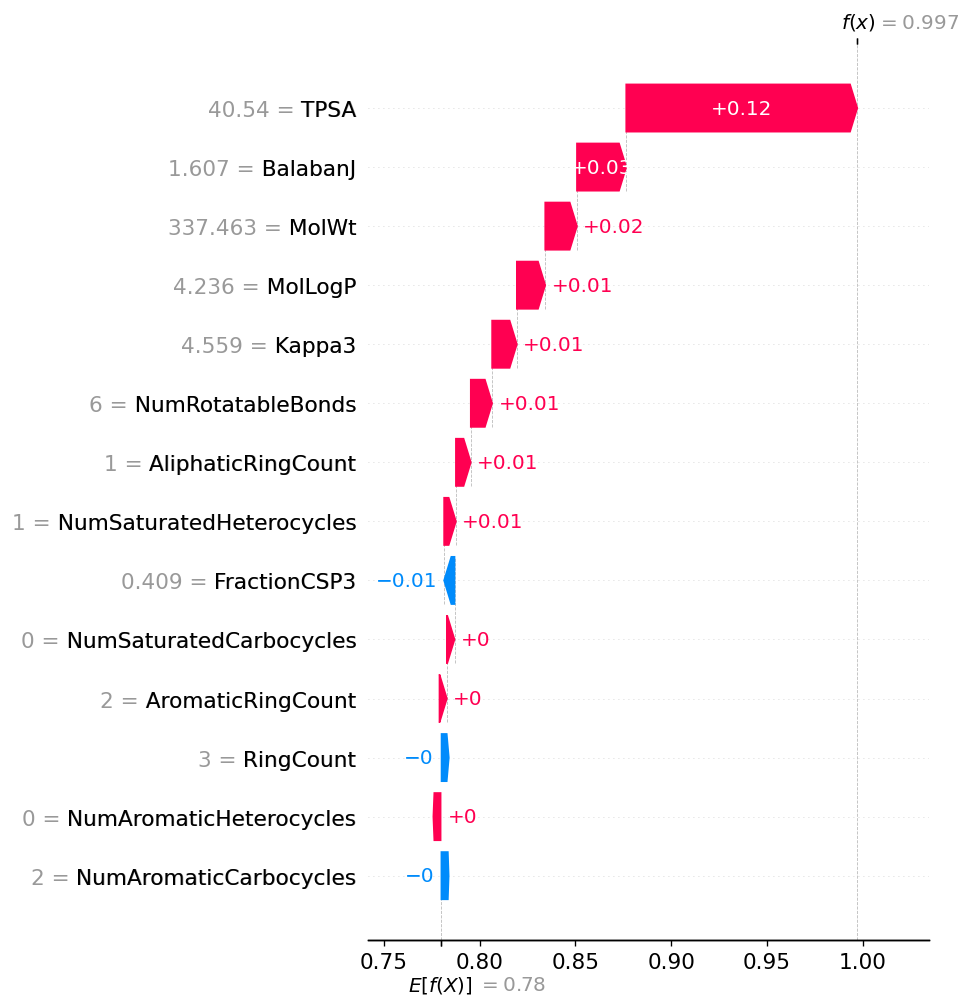

In [26]:
sample_idx = 0

x_one = X_test_explain.iloc[[sample_idx]]

print("Molecule:")
display(test_info.iloc[[sample_idx]])

print("Predicted probability of BBB permeability:")
print(gb_model.predict_proba(x_one)[0, 1])

if sample_idx < len(shap_values):
    shap_explanation = shap_values[sample_idx]
else:
    shap_explanation = explainer(x_one)[0]

with plt.rc_context({"figure.dpi": 120}):
    shap.plots.waterfall(
        shap_explanation,
        max_display=len(feature_cols),
        show=False,
    )
    plt.tight_layout()
    plt.show()

## 9. LIME: local surrogate explanations

LIME explains one prediction by fitting a simple local surrogate model near the sample being explained.

For classification, LIME generates perturbed descriptor vectors, predicts them with the black-box model, weights them by distance to the original sample, and fits a sparse local classifier.

The explanation should be trusted only if the local surrogate has reasonable fidelity.

#### Exercise 5 — Compare SHAP and LIME explanations for the same molecule

In the previous exercise, you computed SHAP values and made a SHAP beeswarm plot. Now you will compare a local SHAP explanation with a local LIME explanation for the same test-set molecule.

SHAP and LIME both explain individual predictions, but they do so differently:

- **SHAP** assigns additive feature contributions relative to a background prediction.
- **LIME** perturbs the selected molecule, asks the model for predictions, and fits a simple local surrogate model.

In this exercise, the SHAP code is already provided. Your task is to complete the LIME parts.

Your tasks:

1. Create a LIME explainer using [`LimeTabularExplainer`](https://lime-ml.readthedocs.io/en/latest/lime.html#lime.lime_tabular.LimeTabularExplainer).
2. Use LIME to explain a selected test-set molecule via [`explain_instance`](https://lime-ml.readthedocs.io/en/latest/lime.html#lime.lime_tabular.LimeTabularExplainer.explain_instance).
3. Plot the LIME explanation and compare the LIME explanation with the SHAP waterfall plot.

In [27]:
# TODO 1:
# Create a LIME tabular explainer.
# This object stores information about the training data and will later be used to generate local explanations for individual test-set molecules.
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train[feature_cols].to_numpy(),
    feature_names=feature_cols,
    class_names=["not BBB permeable", "BBB permeable"],
    mode="classification",
    # Convert continuous descriptor values into intervals/bins. This can make explanations easier to read.
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)

def lime_predict_proba(X_array):
    """
    Prediction function used by LIME.

    LIME will call this function many times on perturbed versions of a molecule.

    Input:
        X_array:
            NumPy array of molecular descriptor values.

    Output:
        Predicted class probabilities from the gradient boosted tree model.
    """
    X_df = pd.DataFrame(X_array, columns=feature_cols)
    return gb_model.predict_proba(X_df)

Sample index: 0
Predicted probability of BBB permeability: 0.997
True label from y_test: 1

Molecule:


,sample_idx,model_df_index,name,smiles,p_np,MolWt,MolLogP,TPSA,NumRotatableBonds,FractionCSP3,RingCount,AromaticRingCount,AliphaticRingCount,NumAromaticHeterocycles,NumAromaticCarbocycles,NumSaturatedHeterocycles,NumSaturatedCarbocycles,BalabanJ,Kappa3,y_test
0,0,1882,lobeline,C3=C(C(CC2N(C(CC(C1=CC=CC=C1)=O)CCC2)C)O)C=CC=C3,1,337.463,4.236,40.54,6,0.409091,3,2,1,0,2,1,0,1.60657,4.559099,1



SHAP waterfall plot:


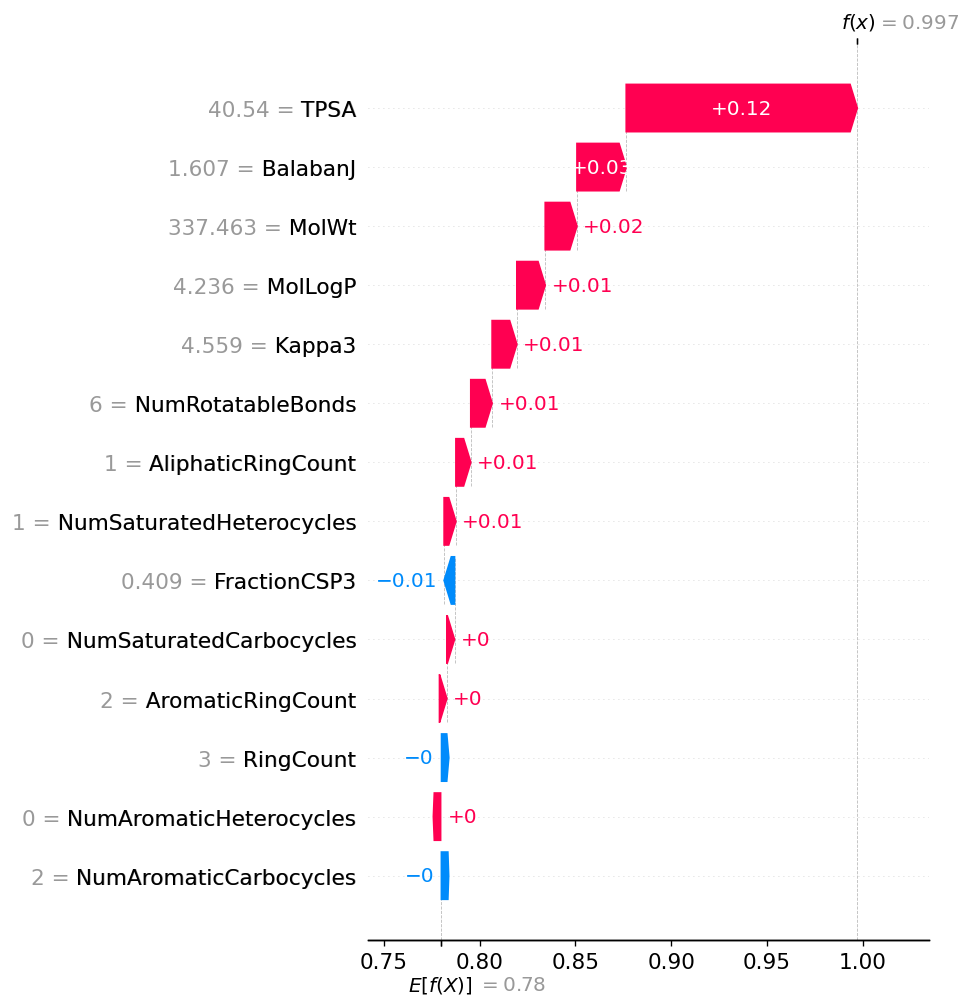


LIME explanation:
LIME local surrogate R²: 0.107


,condition,LIME weight for BBB permeable class
0,32.78 < TPSA <= 54.37,0.188107
1,Kappa3 > 4.37,-0.145477
2,NumSaturatedCarbocycles <= 0.00,0.065293
3,0.30 < FractionCSP3 <= 0.43,-0.046494
4,BalabanJ <= 1.62,0.044182
5,1.00 < AromaticRingCount <= 2.00,0.027156


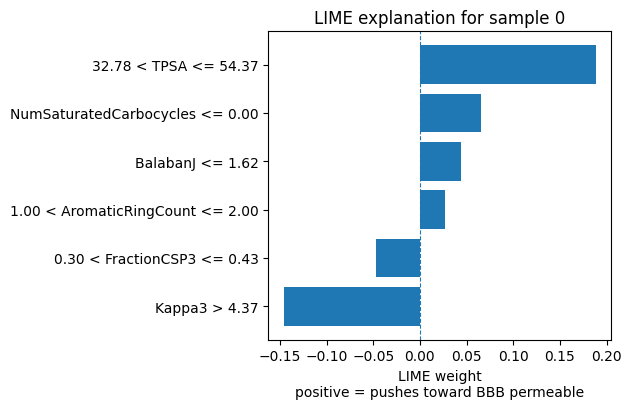

In [28]:
def explain_with_shap_and_lime(sample_idx, num_features=6, num_samples=5000):
    """
    Explain one test-set molecule using both SHAP and LIME.

    Parameters
    ----------
    sample_idx:
        Positional row number in X_test_explain/test_info. This ensures that the SHAP and LIME explanations all refer to the same test-set molecule.

    num_features:
        Number of LIME explanation terms to display.

    num_samples:
        Number of perturbed samples LIME generates around the selected molecule.
        More samples can make the LIME explanation more stable, but also slower.

    Returns
    -------
    results:
        Dictionary containing:
            sample_idx
            predicted_probability
            SHAP explanation object
            LIME explanation object
            LIME explanation terms
    """

    # Check that sample_idx is valid.
    if sample_idx < 0 or sample_idx >= len(X_test_explain):
        raise ValueError(
            f"sample_idx must be between 0 and {len(X_test_explain) - 1}"
        )

    # Select the molecule's descriptor row.
    x_one = X_test_explain.iloc[[sample_idx]]

    # Compute predicted probability of BBB permeability.
    pred_prob = gb_model.predict_proba(x_one)[0, 1]

    # Display molecule metadata and descriptor values.
    print(f"Sample index: {sample_idx}")
    print(f"Predicted probability of BBB permeability: {pred_prob:.3f}")
    print(f"True label from y_test: {y_test[sample_idx]}")

    print("\nMolecule:")
    display(test_info.iloc[[sample_idx]])

    # -----------------------------------------------------------------
    # SHAP explanation
    # -----------------------------------------------------------------
    #
    # If sample_idx was included in the precomputed SHAP subset, reuse the existing SHAP values.
    # Otherwise, compute SHAP values for this one molecule on the fly.
    if sample_idx < len(shap_values):
        shap_explanation = shap_values[sample_idx]
    else:
        shap_explanation = explainer(x_one)[0]

    print("\nSHAP waterfall plot:")

    with plt.rc_context({"figure.dpi": 120}):
        shap.plots.waterfall(
            shap_explanation,
            max_display=len(feature_cols),
            show=False,
        )
        plt.tight_layout()
        plt.show()

    # -----------------------------------------------------------------
    # LIME explanation
    # -----------------------------------------------------------------

    # TODO 2:
    # Use lime_explainer.explain_instance to generate a local surrogate model around the selected molecule.
    # This explainer will generate a local surrogate model around the selected molecule and returns an explanation object.
    exp = lime_explainer.explain_instance(
        data_row=X_test_explain.iloc[sample_idx].to_numpy(),
        predict_fn=lime_predict_proba,
        num_features=num_features,
        num_samples=num_samples,
        labels=[1],
    )
    # Convert the results into a readable DataFrame.
    lime_terms = pd.DataFrame(
        exp.as_list(label=1),
        columns=["condition", "LIME weight for BBB permeable class"],
    )

    # Print, display, and plot all results.
    print("\nLIME explanation:")

    if hasattr(exp, "score"):
        print(f"LIME local surrogate R²: {exp.score:.3f}")

    display(lime_terms)

    plot_df = lime_terms.sort_values(
        "LIME weight for BBB permeable class"
    )

    fig, ax = plt.subplots(figsize=(6.4, 4.2))

    ax.barh(
        plot_df["condition"],
        plot_df["LIME weight for BBB permeable class"],
    )

    ax.axvline(0, linewidth=0.8, linestyle="--")

    ax.set_xlabel(
        "LIME weight\n"
        "positive = pushes toward BBB permeable"
    )

    ax.set_title(f"LIME explanation for sample {sample_idx}")

    plt.tight_layout()
    plt.show()

    return {
        "sample_idx": sample_idx,
        "predicted_probability": pred_prob,
        "shap_explanation": shap_explanation,
        "lime_explanation": exp,
        "lime_terms": lime_terms,
    }

results = explain_with_shap_and_lime(sample_idx=0)

Pause to consider the results (and see the answer key for some of my thoughts).

For LIME plots, consider:

- Does the explanation agree with SHAP for this molecule?
- Is the local surrogate fidelity acceptable?
- Are the feature intervals chemically plausible?
- How much does the explanation change if we used a different random seed or number of samples?

LIME depends on a local perturbation cloud, the number of perturbed samples, and random state. A useful explanation should not change dramatically under small reasonable changes. It is always worth checking whether the explanation changes when `num_samples` or `num_features` is varied.

For lobeline, the model predicts BBB permeability with very high confidence, and the prediction agrees with the true label. SHAP shows that the prediction is driven mainly by the molecule's moderate TPSA, which strongly increases the predicted probability of BBB permeability relative to the background prediction. LIME also identifies the same TPSA range as the strongest positive contributor, although the LIME local surrogate has a very low R^2, indicating that the LIME explanation should be interpreted cautiously. In this case, I would start by increasing `num_features` (feel free to try this yourself)!

## 10. Fingerprint-bit interpretation

Many chemical ML models use molecular fingerprints rather than hand-selected descriptors. This representation is less directly interpretable than descriptors, but individual fingerprint bits can be mapped back to molecular substructures.

Here, we train a GB tree model on Morgan fingerprints and inspect important bits.

Gradient boosted trees on Morgan fingerprints
---------------------------------------------
accuracy            : 0.878
balanced_accuracy   : 0.765
roc_auc             : 0.880


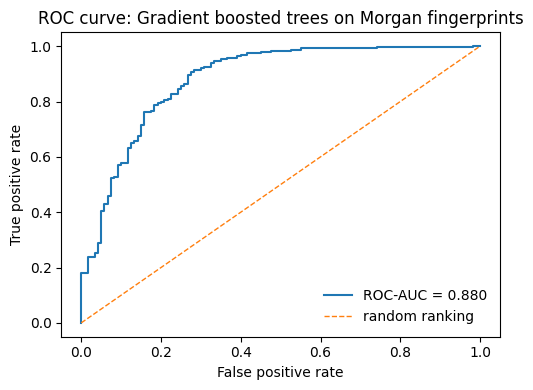

In [29]:
n_bits = 1024

fp_source = (
    model_df
    .dropna(subset=["mol", "p_np"])
    .copy()
)

# Create a Morgan fingerprint generator.
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=n_bits,
)

# Compute Morgan fingerprints for every molecule.
fp_array = np.vstack([
    morgan_generator.GetFingerprintAsNumPy(mol)
    for mol in fp_source["mol"]
])

# Convert the fingerprint array into a DataFrame.
fp_df = pd.DataFrame(
    fp_array,
    columns=[f"bit_{i}" for i in range(n_bits)],
    index=fp_source.index,
)

# Labels and indices must come from fp_source too.
y_fp = fp_source["p_np"].astype(int).to_numpy()
idx_fp = fp_source.index.to_numpy()

# Sanity check that fingerprints, labels, and indices are aligned.
assert len(fp_df) == len(y_fp) == len(idx_fp)

# Split the fingerprint dataset into training and test sets.
# Again, we stratify by the BBBP label to ensure that both sets have similar class distributions.
Xfp_train, Xfp_test, yfp_train, yfp_test, idxfp_train, idxfp_test = (
    train_test_split(
        fp_df,
        y_fp,
        idx_fp,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y_fp,
    )
)


# Define a gradient boosted tree classifier with a fixed set of reasonable hyperparameters.
gb_fp_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=2,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=RANDOM_STATE,
)

# Fit the model using only the fingerprint training set.
gb_fp_model.fit(Xfp_train, yfp_train)

# Evaluate the trained fingerprint model once on the held-out test set.
gb_fp_metrics = evaluate_classifier(
    gb_fp_model,
    Xfp_test,
    yfp_test,
    name="Gradient boosted trees on Morgan fingerprints",
)

Our new model performs well compared to the previous one and I skipped hyperparameter tuning entirely. As an optional exercise, go ahead and try to tune hyperparameters yourself!

At this point, we could return to any of the model-agnostic interpretability methods we applied previously. For the sake of the tutorial, here we will inspect MDI feature importances as we have not applied this method yet. Tree-based models provide a built-in feature-importance measure called **mean decrease in impurity**, or **MDI**. A larger MDI value means that the model used that feature more often, or more effectively, to split the data during training. If desired, feel free to explore this model using any of the methods shown previously in this notebook or others! When doing so, always consider whether it makes sense to apply the methods given their limitations.

In this model, each feature is a fingerprint bit, which represents the presence or absence of one or more circular molecular substructures. The plot below shows the fingerprint bits with the largest mean decrease in impurity, meaning these bits were most useful for splitting the data in the trained tree model.

### Exercise 6 — Interpret Morgan fingerprint bits with MDI importance

In this short final exercise, you will inspect which Morgan fingerprint bits were most important to the gradient boosted tree model.

Your tasks:

1. Extract MDI feature importances from the trained fingerprint model using [`GradientBoostingClassifier.feature_importances_`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html).
2. Display/plot the importances of the top bits.

,MDI importance
bit_5,0.088661
bit_357,0.085654
bit_387,0.058503
bit_233,0.052975
bit_807,0.046622
bit_578,0.044706
bit_573,0.026061
bit_519,0.025922
bit_128,0.022357
bit_23,0.022139


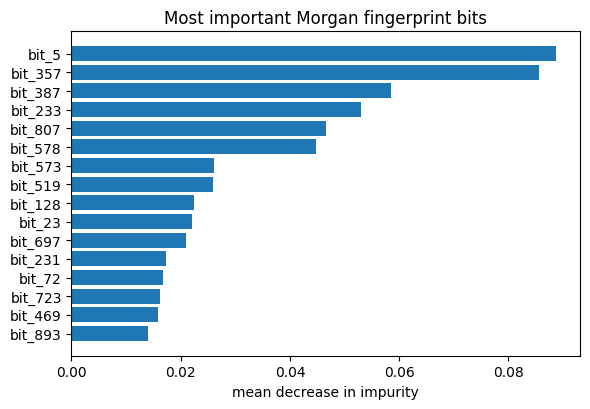

In [30]:
# TODO 1:
# Create a pandas Series containing the MDI importance of each fingerprint bit.
fp_importance = pd.Series(
    gb_fp_model.feature_importances_,
    index=fp_df.columns,
).sort_values(ascending=False)

# TODO 2:
# Select a subset of the most important bits to display and plot.
top_bits = fp_importance.head(16)

# Display and plot the most important fingerprint bits.
display(top_bits.rename("MDI importance").to_frame())

fig, ax = plt.subplots(figsize=(6.0, 4.2))

plot_df = top_bits.sort_values()
ax.barh(plot_df.index, plot_df.values)
ax.set_xlabel("mean decrease in impurity")
ax.set_title("Most important Morgan fingerprint bits")

plt.tight_layout()
plt.show()

Next, we draw the important Morgan fingerprint bits. Biggest caveat here is that a fingerprint bit can correspond to multiple possible substructures because of hashing (this is something we should check for by drawing important bits from more than one molecule).


Fingerprint bit: 5
Example molecule index: 4


,name,smiles,p_np
4,cloxacillin,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...,1


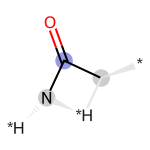


Fingerprint bit: 357
Example molecule index: 25


,name,smiles,p_np
25,12,CCNC(=NC#N)NCCSCc1c(cccn1)Br,0


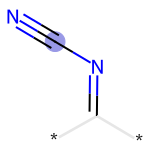


Fingerprint bit: 387
Example molecule index: 4


,name,smiles,p_np
4,cloxacillin,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...,1


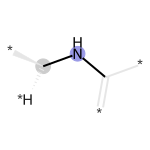


Fingerprint bit: 233
Example molecule index: 4


,name,smiles,p_np
4,cloxacillin,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...,1


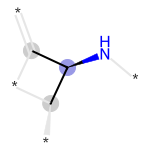


Fingerprint bit: 807
Example molecule index: 0


,name,smiles,p_np
0,Propanolol,[Cl].CC(C)NCC(O)COc1cccc2ccccc12,1


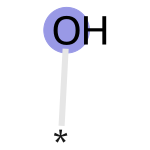


Fingerprint bit: 578
Example molecule index: 5


,name,smiles,p_np
5,cefoperazone,CCN1CCN(C(=O)N[C@@H](C(=O)N[C@H]2[C@H]3SCC(=C(...,1


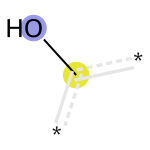


Fingerprint bit: 573
Example molecule index: 5


,name,smiles,p_np
5,cefoperazone,CCN1CCN(C(=O)N[C@@H](C(=O)N[C@H]2[C@H]3SCC(=C(...,1


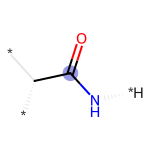


Fingerprint bit: 519
Example molecule index: 6


,name,smiles,p_np
6,rolitetracycline,CN(C)[C@H]1[C@@H]2C[C@H]3C(=C(O)c4c(O)cccc4[C@...,1


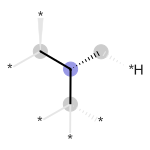

In [31]:
def get_morgan_bit_info(mol, radius=2, n_bits=1024):
    """
    Compute Morgan fingerprint bit information for one molecule.

    Parameters
    ----------
    mol:
        RDKit molecule object.

    radius:
        Morgan fingerprint radius.

    n_bits:
        Length of the hashed fingerprint vector.

    Returns
    -------
    bit_info:
        Dictionary mapping fingerprint bit IDs to the atom environments that activated those bits.

    """

    # Compute the Morgan fingerprint as a bit vector.
    morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
        radius=radius,
        fpSize=n_bits,
    )

    # Create an object that will store extra fingerprint information.
    additional_output = rdFingerprintGenerator.AdditionalOutput()

    # Request the bit-to-atom-environment mapping.
    additional_output.AllocateBitInfoMap()

    # Compute the fingerprint.
    _ = morgan_generator.GetFingerprint(
        mol,
        additionalOutput=additional_output,
    )

    # Extract the mapping from fingerprint bits to atom environments.
    bit_info = additional_output.GetBitInfoMap()

    return bit_info

def find_molecule_with_bit(bit_id, model_df, radius=2, n_bits=1024):
    """
    Find the first molecule in model_df that activates a specific Morgan fingerprint bit.

    Parameters
    ----------
    bit_id:
        Integer ID of the fingerprint bit to search for.

    model_df:
        DataFrame containing a column called "mol" with RDKit molecule objects.

    radius:
        Morgan fingerprint radius.

    n_bits:
        Length of the hashed fingerprint vector.

    Returns
    -------
    row_idx:
        Index of the first molecule containing the bit.

    mol:
        RDKit molecule object for that molecule.

    bit_info:
        Morgan fingerprint bit information for that molecule.

    """
    # Loop through every molecule in model_df.
    for row_idx, mol in model_df["mol"].items():
        # Compute the Morgan fingerprint bit information for this molecule.
        bit_info = get_morgan_bit_info(mol, radius=radius, n_bits=n_bits)
        # Check whether this molecule activates the bit of interest and return the first matching molecule.
        if bit_id in bit_info:
            return row_idx, mol, bit_info
    # If no molecule contains this bit, return empty values.
    return None, None, None

# Loop over the eight most important fingerprint bits and find an example molecule that activates this fingerprint bit.
for bit_name in top_bits.index[:8]:

    bit_id = int(bit_name.split("_")[1])

    row_idx, mol, bit_info = find_molecule_with_bit(
        bit_id,
        model_df,
        radius=2,
        n_bits=n_bits,
    )

    if mol is None:
        print(f"Could not find molecule containing bit {bit_id}.")
        continue

    print(f"Fingerprint bit: {bit_id}")
    print(f"Example molecule index: {row_idx}")
    display(model_df.loc[[row_idx], ["name", "smiles", "p_np"]])

    try:
        # Draw the molecular environment corresponding to this fingerprint bit.
        img = Draw.DrawMorganBit(
            mol,
            bit_id,
            bit_info,
            useSVG=False,
        )
        display(img)
    except Exception as exc:
        print(f"Could not draw bit {bit_id}: {exc}")

    print()

Pause to consider the results (and see the answer key for some of my thoughts).

The Morgan fingerprint model relied most strongly on a small number of substructure bits. Taking a look at the important bit structures, it seems that the fingerprint model is using local chemical environments related to polarity and hydrogen bonding, which is chemically plausible for BBB permeability. However, these fingerprint bits should be interpreted cautiously. Because Morgan fingerprints are hashed, a single bit may correspond to multiple substructures, and the examples shown here are only the first molecules found that activate each bit. In addition, MDI importance tells us which bits the model used, but not whether those bits push predictions toward BBB-permeable or BBB-nonpermeable.

As a next step, let's take a look at whether the presence/absence of these bits is contributing to BBB permeability or nonpermeability.

In [32]:
bit_summary = []

for bit_name in top_bits.index:
    bit_present = fp_df[bit_name] == 1

    bit_summary.append({
        "bit": bit_name,
        "MDI importance": fp_importance[bit_name],
        "number with bit": bit_present.sum(),
        "fraction with bit": bit_present.mean(),
        "BBB-positive fraction when bit present": y_fp[bit_present].mean(),
        "BBB-positive fraction when bit absent": y_fp[~bit_present].mean(),
    })

bit_summary_df = (
    pd.DataFrame(bit_summary)
    .sort_values("MDI importance", ascending=False)
)

display(bit_summary_df)

,bit,MDI importance,number with bit,fraction with bit,BBB-positive fraction when bit present,BBB-positive fraction when bit absent
0,bit_5,0.088661,166,0.081412,0.240964,0.811532
1,bit_357,0.085654,69,0.033840,0.130435,0.787310
2,bit_387,0.058503,165,0.080922,0.272727,0.808431
3,bit_233,0.052975,433,0.212359,0.489607,0.839352
4,bit_807,0.046622,1328,0.651300,0.682982,0.918425
5,bit_578,0.044706,214,0.104953,0.500000,0.796164
6,bit_573,0.026061,128,0.062776,0.265625,0.798535
7,bit_519,0.025922,240,0.117705,0.800000,0.760422
8,bit_128,0.022357,542,0.265817,0.577491,0.832999
9,bit_23,0.022139,41,0.020108,0.487805,0.770771


Pause to consider the results (and see the answer key for some of my thoughts).

The bit summary table shows that many of the most important Morgan fingerprint bits are associated with lower BBB-positive fractions when present. For example, molecules containing `bit_5`, `bit_357`, or `bit_387` are much less likely to be BBB-positive than molecules lacking those bits. This suggests that the fingerprint model is using several local substructure patterns as signals for BBB non-penetration. Many of these bits appear to correspond to heteroatom-rich or polar local environments, which is chemically plausible because BBB permeability is strongly influenced by polarity, hydrogen bonding, and desolvation. However, again, these results should still be interpreted cautiously: fingerprint bits are hashed and some bits are rare.

## 11. Capstone exercise — Design a model interpretation workflow around your own question

In this final exercise, you will design an end-to-end chemical machine learning workflow motivated by a question you have about the BBBP dataset.

So far, we have used a fixed set of descriptors, a fixed model, and several interpretation methods. Now your task is to start with a question and make modeling choices that help you answer it.

Your goal is to build a workflow that connects:

$$
\text{question} \rightarrow \text{features} \rightarrow \text{model} \rightarrow \text{evaluation} \rightarrow \text{interpretation}
$$

At each step, ask yourself whether your choices help answer your original question.

You should complete the full workflow:

1. Propose a question about the BBBP dataset.
2. Choose a molecular representation that is appropriate for your question.
3. Choose and train a model.
4. Evaluate model performance.
5. Choose interpretation methods that match your question.
6. Use your results to answer your original question.
7. Discuss limitations and what you would try next.

Feel free to use any code from earlier in the notebook.